# PART A: Exploratory Data Analysis & Preprocessing

The initial step I will take is to load the data and investigate the different data types in each column, do a quality check, understand the frequency of distribution for the target variable. I would also look to put the ttarget variable at a glance and determine which features are of high importance 

## Data Upload and Libraries

We begin by uploading the data and importing libraries required for initial data exploration

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train_data=pd.read_csv("dataset_train.csv")
test_data=pd.read_csv("dataset_test.csv")

In [133]:
print(train_data.info)

train_data.describe().T
print(test_data.info)

test_data.describe().T

<bound method DataFrame.info of                 0         1          2          3          4          5  \
0      15596.1621  1.868245   2.371604   2.803678   7.512213  -2.739388   
1      26402.0704  2.532401   5.411209   6.509906   7.658469  -4.722217   
2      42103.5820  3.454189   8.198175  10.508439  11.611003  -7.668313   
3      42825.9883  3.451192  12.113940  16.266853  39.910056  -7.849409   
4      58151.1757  4.194839  11.455096  15.715298  17.654915 -11.083364   
...           ...       ...        ...        ...        ...        ...   
3431  207179.5547  6.517899  56.616359  80.202538  97.060328 -37.810355   
3432  204744.0547  6.448759  56.258271  79.929722  94.826653 -37.188191   
3433  203670.7695  6.399488  55.740010  78.982899  91.938293 -36.967799   
3434  204322.7890  6.421564  55.773479  80.560998  98.967496 -37.076589   
3435  203561.3946  6.410383  55.699448  79.667087  97.659231 -36.839495   

              6           7            8         9  ...        119 

,count,mean,std,min,25%,50%,75%,max
0,1716.0,43351.992622,56401.099852,-1377.306600,6020.270425,24011.704100,51655.339450,280431.783200
1,1716.0,5.598826,4.820403,0.852502,2.033458,3.678860,8.124317,29.147021
2,1716.0,11.144969,14.478025,0.036450,2.012357,5.435528,13.685605,83.680018
3,1716.0,16.008548,21.411599,0.269042,2.949712,7.495879,19.089972,128.112090
4,1716.0,27.705161,48.825190,2.250820,5.868272,11.219774,27.443728,664.208067
...,...,...,...,...,...,...,...,...
124,1716.0,15.620535,11.623470,3.267195,7.651663,12.074531,19.974911,79.152049
125,1716.0,-4.170057,5.571512,-30.205911,-4.667737,-2.442981,-0.980262,-0.070422
126,1716.0,-7.571319,10.664052,-58.773503,-8.235421,-4.176326,-1.686866,-0.357976
127,1716.0,-17.928331,28.902601,-208.792404,-15.994537,-8.704476,-5.209189,-2.176613


In [134]:
print(train_data.head(3))

            0         1         2          3          4         5         6  \
0  15596.1621  1.868245  2.371604   2.803678   7.512213 -2.739388 -3.344671   
1  26402.0704  2.532401  5.411209   6.509906   7.658469 -4.722217 -5.817651   
2  42103.5820  3.454189  8.198175  10.508439  11.611003 -7.668313 -9.478675   

           7           8         9  ...       119        120       121  \
0  -4.847512  15326.6914  1.768526  ... -3.037772  3037.0390  3.972203   
1  -7.518333  23855.7812  2.164706  ... -1.994993  4176.4453  4.281373   
2 -12.230939  37562.3008  2.840403  ... -2.867291  5914.6685  5.396827   

        122       123       124       125       126       127  target  
0  0.527291  0.728443  1.445783 -0.545079 -0.902241 -2.654529     1.0  
1  0.980205  1.628050  1.951172 -0.889333 -1.323505 -1.749225     1.0  
2  1.403973  2.476956  3.039841 -1.334558 -1.993659 -2.348370     1.0  

[3 rows x 129 columns]


## Counts and Missing values
We carry out frequency count of the target variable and note that gas 6 occurs least with 2 occuring the highest number of times, we also observe the data does not have missing values and we proceed to plot the distribution of the target variable. We note that due to the distribution of gas 6 we might need to enforce class weight balance as the ttarget variable is unbalances in training.

target
2.0    965
5.0    889
1.0    683
3.0    411
4.0    409
6.0     79
Name: count, dtype: int64


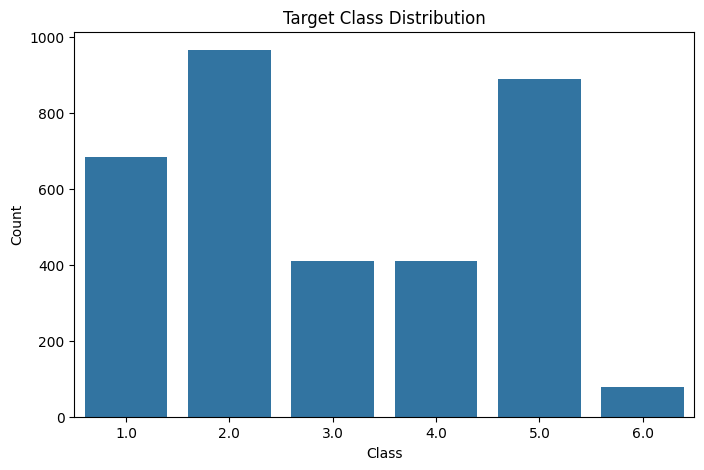

In [135]:
print(train_data['target'].value_counts())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x="target")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

target
1.0    286
2.0    286
3.0    286
4.0    286
5.0    286
6.0    286
Name: count, dtype: int64


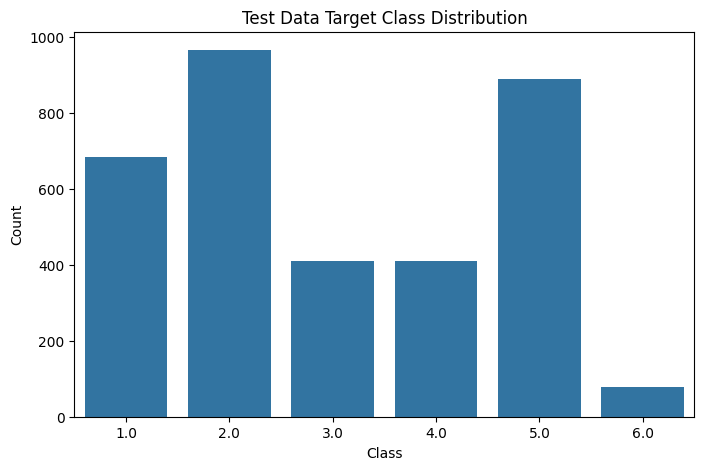

In [136]:
print(test_data['target'].value_counts())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x="target")
plt.title("Test Data Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [137]:
missing_values = train_data.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


## Feature Engineering
### Feature correlation
Next I want to have a peak at the features that are highly correlated, we have 128 features and the correlation matrix will be extremely large so I will only generate the matrix for features that are highly correlated. This is important because highly correlated features may be redundant and we can utilise lasso to determine which of the features are important to the target variable. 
To begin this we break down the training data into the features and the target. From this we see that the lowest correlation is 0.9753, which means that all features are highly correlated and majority might be redundant. 
We then resort to carrying out a PCA of our features 

In [138]:
X_train=train_data.drop(columns=["target"])
y_train=train_data["target"]

In [139]:
X_test=test_data.drop(columns=["target"])
y_test=test_data["target"]

In [140]:
import numpy as np

corr_matrix = X_train.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > 0.9].sort_values(
    by="Correlation", ascending=False
)

high_corr_pairs.head(128)

,Feature_1,Feature_2,Correlation
4402,41,57,0.999867
5054,49,57,0.999841
4394,41,49,0.999420
8030,113,121,0.999117
8080,117,125,0.998678
...,...,...,...
6539,71,79,0.975470
261,2,11,0.975442
5744,58,90,0.975323
1916,16,21,0.975313


Next we run on PCA to check the and we notice there is significant change in variance up to the 16th feature but past that there is only 5% change in variance. This means 16 features explain for the 0.95 %change in variance and the 112 explain for the 5 %, this further strengthens what we had learnt earlier thbat there are multiple redundant features. Also 0.42 %change in variance is expplained by a single component.

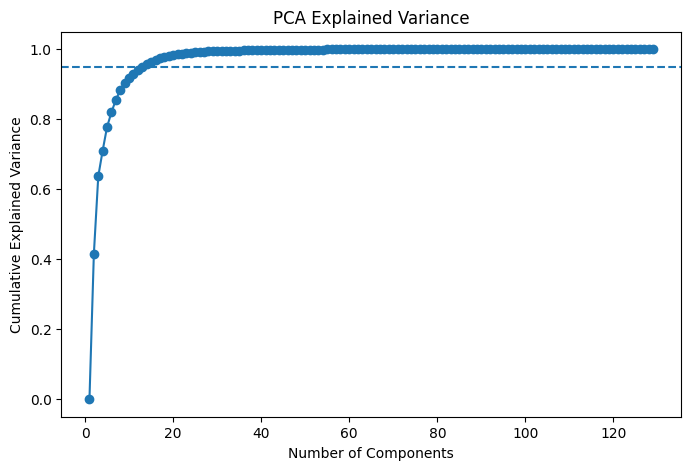

In [141]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance = np.insert(cumulative_variance, 0, 0) 

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(0.95, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

Then we also run a K means clustering and note that the 6 gasses form definite clusters , however cluster 2,4 and 5 have regions of overlap and this might cause difficulty in accurately predicting the 3 gases. Another important observation is that we have non-linear boundaries between the gases, when selecting a model this should come into consideration.

cluster    1    2    3    4   5  6
target                            
1.0        0  426  220    5  31  1
2.0        0    5  285  665  10  0
3.0        0   26  384    1   0  0
4.0       16  104  279    0  10  0
5.0      500    3  386    0   0  0
6.0        0    0   79    0   0  0


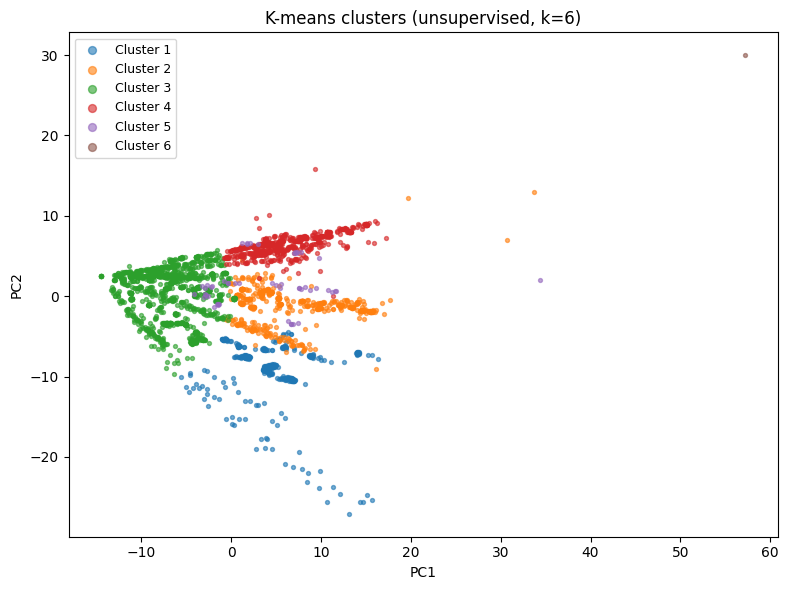

In [142]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
train_data["cluster"] = cluster_labels+1

print(pd.crosstab(train_data["target"], train_data["cluster"]))



X_pca = PCA(n_components=2).fit_transform(X_scaled)

colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(6):
    mask = cluster_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], s=8, alpha=0.6, label=f"Cluster {i+1}")

ax.set_title("K-means clusters (unsupervised, k=6)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()


**Note: this is an experiment phase we will not proceed with its output**
- next is an experiemnt I am looking to convert the 128 columns into 16 columns cause the 128 columns have high correlation and PCA shows 16 features attribute for 0.95 change in variance, this means that there is a lot of redundancy in the data and considering we have 16 sensors with 8 features I have made the conclusion that 8 corresponding features are from one sensor. I create a new dataset with 16 features formed from combining 8 features via their means.

In [143]:
X_train16 = pd.DataFrame(
    X_train.values.reshape(len(X_train), 16, 8).mean(axis=2),
    columns=[f"sensor_{k}" for k in range(16)]
)

print(X_train16.shape)  
print(X_train16.head())



(3436, 16)
      sensor_0     sensor_1    sensor_2    sensor_3    sensor_4    sensor_5  \
0  1949.973284  1916.216324  349.070354  323.045159   85.857047   99.932215   
1  3300.765523  2982.346389  485.828700  456.816705  123.110491  145.552528   
2  5263.496985  4696.137369  685.096718  643.145298  176.436720  206.271346   
3  5358.533667  4802.542112  709.671169  668.765989  187.812436  218.806689   
4  7269.890493  6497.953147  936.236625  875.165451  247.347371  286.296400   

      sensor_6     sensor_7     sensor_8     sensor_9    sensor_10  \
0   391.519703   392.381903  1693.071038  1728.784328   378.043423   
1   542.079703   548.957473  2569.490897  2817.983068   530.493346   
2   768.942257   775.427804  4046.416626  4450.240603   746.660532   
3   796.158502   806.492458  4166.480738  4564.878071   774.312480   
4  1060.323169  1069.386547  5652.564455  6209.747966  1016.878038   

    sensor_11   sensor_12   sensor_13    sensor_14    sensor_15  
0  273.633312  108.079375  

In [144]:
X_test16 = pd.DataFrame(
    X_test.values.reshape(len(X_test), 16, 8).mean(axis=2),
    columns=[f"sensor_{k}" for k in range(16)]
)

print(X_test16.shape)  
print(X_test16.head())



(1716, 16)
       sensor_0     sensor_1     sensor_2     sensor_3    sensor_4  \
0   6813.529215  7398.524485  1628.173321  1654.325260  605.346076   
1   7745.394348  5771.039014  1230.101401  1222.561507  453.043747   
2    834.991562   451.769114   120.865146   119.366292   43.754889   
3   8292.902892  7332.607338  1563.244495  1591.298083  596.785730   
4  10489.437209  9474.552654  2235.583048  2251.347474  778.127100   

     sensor_5     sensor_6     sensor_7      sensor_8     sensor_9  \
0  517.541312  2218.689912  2264.849383   8265.186354  6861.674580   
1  384.838935  1778.078708  1827.958080   8106.701181  7346.019304   
2   35.701118   172.537772   180.154535    775.105762   687.669190   
3  509.284073  2126.527666  2193.417930   8337.928675  6983.465038   
4  669.705193  3086.743144  3199.184638  10929.844682  9240.595424   

     sensor_10    sensor_11   sensor_12   sensor_13    sensor_14    sensor_15  
0  1848.673091  1575.631492  690.875149  615.241411  2597.953886  2

now for this data set with 16 features we go ahead to do somebit of exploration, to check how the features correlate and their correlation to the target variable.

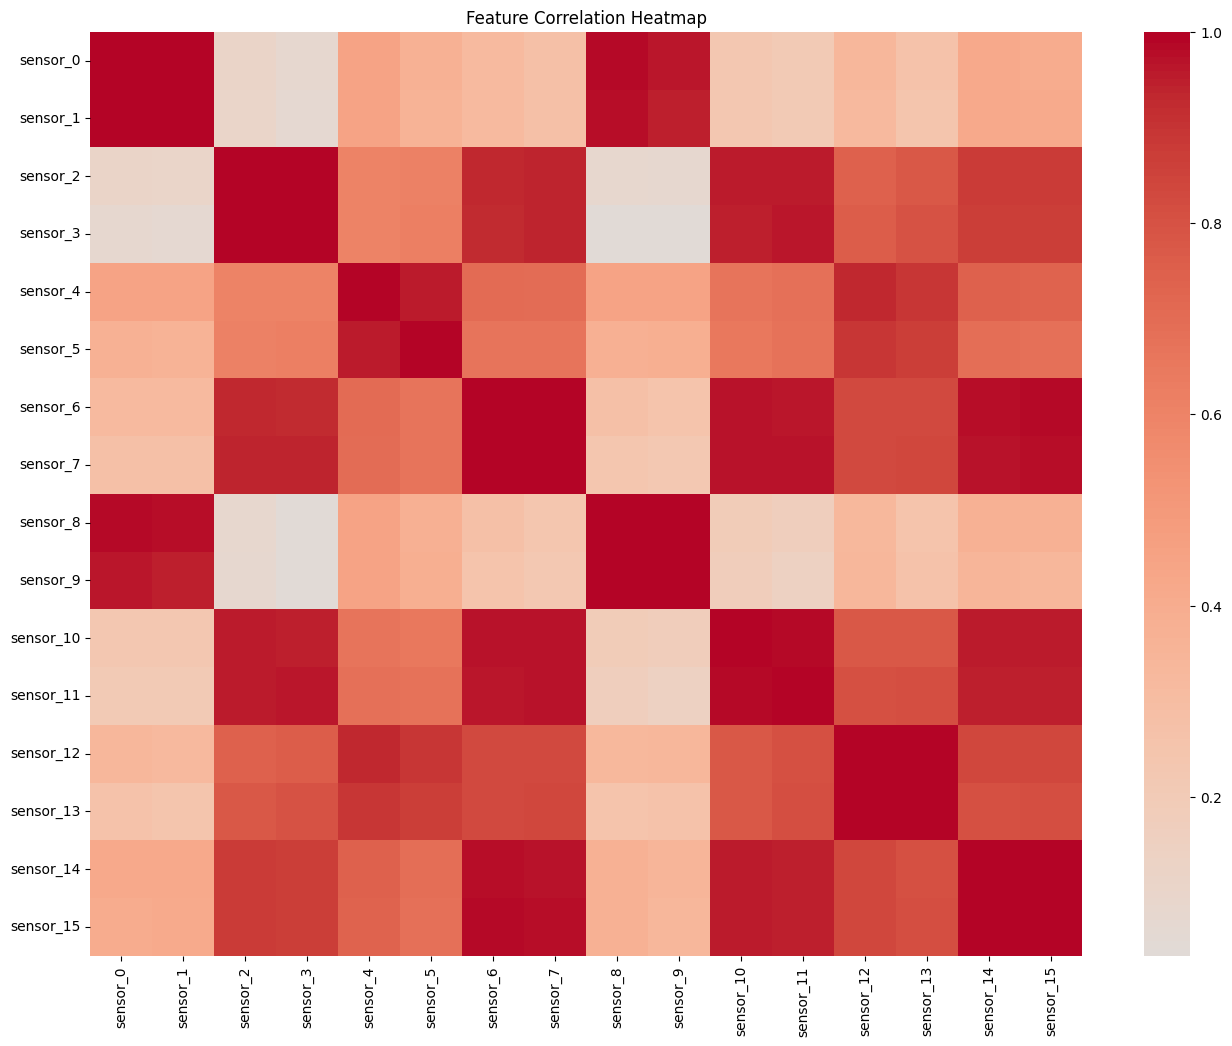

,Feature_1,Feature_2,Correlation
75,sensor_6,sensor_7,0.998365
119,sensor_14,sensor_15,0.998258
0,sensor_0,sensor_1,0.996827
92,sensor_8,sensor_9,0.992005
29,sensor_2,sensor_3,0.990884
114,sensor_12,sensor_13,0.990197
105,sensor_10,sensor_11,0.987604
83,sensor_6,sensor_15,0.982656
7,sensor_0,sensor_8,0.981793
82,sensor_6,sensor_14,0.979995


In [145]:
plt.figure(figsize=(16, 12))
corr_matrix = X_train16.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


corr_matrix = X_train16.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] > 0.9].sort_values(
    by="Correlation", ascending=False
)

high_corr_pairs.head(16)

In [146]:
X_train16.head(2)

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15
0,1949.973284,1916.216324,349.070354,323.045159,85.857047,99.932215,391.519703,392.381903,1693.071038,1728.784328,378.043423,273.633312,108.079375,132.685167,419.920289,379.951359
1,3300.765523,2982.346389,485.828700,456.816705,123.110491,145.552528,542.079703,548.957473,2569.490897,2817.983068,530.493346,385.366062,154.863919,182.755179,586.332413,522.665505


## Lasso Regression for feature selection 

Since we have figured out that majority of the  features are redundant I went on to investigate which features are most important in detrmining the target 
variable. With lasso regression the linear model forces the coefficien  of non important features in predicting the target variable to  to 0, the features that contribute to the target variable are multiplied with non-positive coefficients while those that do
not contribute are multiplied with zero, hence lasso regression cuts through and highlights the important features which should be used 
in prediction.

Alpha chosen: 0.0194
Non-zero features: 16 / 128

Top 20 features:
77     1.718802
8      1.242943
64     1.133067
99     0.357737
113    0.192958
124    0.189484
73     0.157929
11     0.144910
88     0.120004
87     0.084339
97     0.071542
44     0.061938
7      0.035978
117    0.012341
108    0.009795
47     0.009030
69     0.000000
89     0.000000
84     0.000000
90     0.000000
dtype: float64


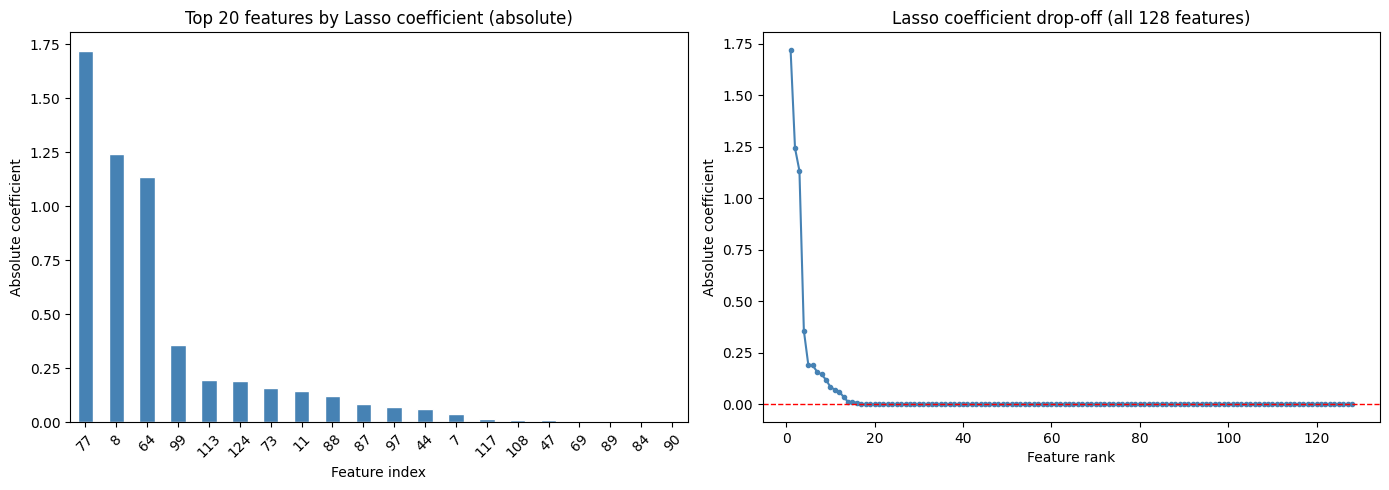

In [147]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y_train)


coef = pd.Series(lasso.coef_, index=[str(i) for i in range(128)])
coef_sorted = coef.abs().sort_values(ascending=False)

print(f"Alpha chosen: {lasso.alpha_:.4f}")
print(f"Non-zero features: {(coef != 0).sum()} / 128")
print(f"\nTop 20 features:\n{coef_sorted.head(20)}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


coef_sorted.head(20).plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Top 20 features by Lasso coefficient (absolute)")
axes[0].set_xlabel("Feature index")
axes[0].set_ylabel("Absolute coefficient")
axes[0].tick_params(axis='x', rotation=45)


coef_sorted.values  
axes[1].plot(range(1, 129), coef_sorted.values, marker='o', markersize=3, color="steelblue")
axes[1].axhline(0, linestyle='--', color='red', linewidth=1)
axes[1].set_title("Lasso coefficient drop-off (all 128 features)")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Absolute coefficient")

plt.tight_layout()
plt.show()

Now we process the dataset and create a new one using only the selected features. We select only the features that have a non zero lasso coefficient.
Next we select the 5 models to train then test their performance
1. Logistic regression
2. K-Nearest Neighbours
3. Random Forests
4. Support vector machines
5. Neural networks

In [148]:
top_features = ['77','8','64','99','113','124','73','11','88','87','97','44','7','117','108','47']


X_train_lasso = train_data[top_features]
X_test_lasso  = test_data[top_features]

print(X_train_lasso.shape)  
print(X_test_lasso.shape)
print(X_train_lasso.head(2))  
print(X_test_lasso.head(2))

(3436, 16)
(1716, 16)
         77           8          64        99       113       124        73  \
0 -2.350776  15326.6914  13540.6738  0.246473  3.860647  1.445783  1.746493   
1 -3.986434  23855.7812  20553.5645  0.558008  4.277604  1.951172  2.222146   

         11         88        87        97        44         7       117  \
0  2.713374  2185.9741 -1.643650  1.779291  0.841862 -4.847512 -0.619214   
1  5.971392  3079.0621 -1.419646  2.067927  0.840494 -7.518333 -1.004812   

        108        47  
0  0.815048 -0.791447  
1  0.950204 -0.718214  
          77           8          64        99       113       124         73  \
0  -9.727009  59153.6262  66116.8472  7.140387  8.211512  26.27274  12.893230   
1 -11.465732  46209.2364  64919.8477  3.851779  6.085116  15.10346   3.452137   

          11          88         87        97        44          7       117  \
0  25.984886  12588.1677 -10.748454  5.324138  8.334744 -27.321621 -5.607348   
1  19.573113   9783.9519 -11.699591

# PART B:  Model Development & Evaluation

## Logistic Regression
This is a classification task withj 6 classes and logistic would be the best model to run for showing a baseline performance, the model is fast given we are using only 16 features for prediction and givenm we have removed the excess features we know that the multiple collinear features will not have an impending effect on it.
Now using the clustering we observed that the gases have somewhat non linear boundaries, however, logistic regression is strong with linear boundaries.

Accuracy          : 0.499
              precision    recall  f1-score   support

     Ethanol       0.32      0.98      0.49       286
    Ethylene       0.55      0.46      0.50       286
     Ammonia       0.69      0.83      0.75       286
Acetaldehyde       0.00      0.00      0.00       286
     Acetone       0.95      0.72      0.82       286
     Toluene       0.00      0.00      0.00       286

    accuracy                           0.50      1716
   macro avg       0.42      0.50      0.43      1716
weighted avg       0.42      0.50      0.43      1716



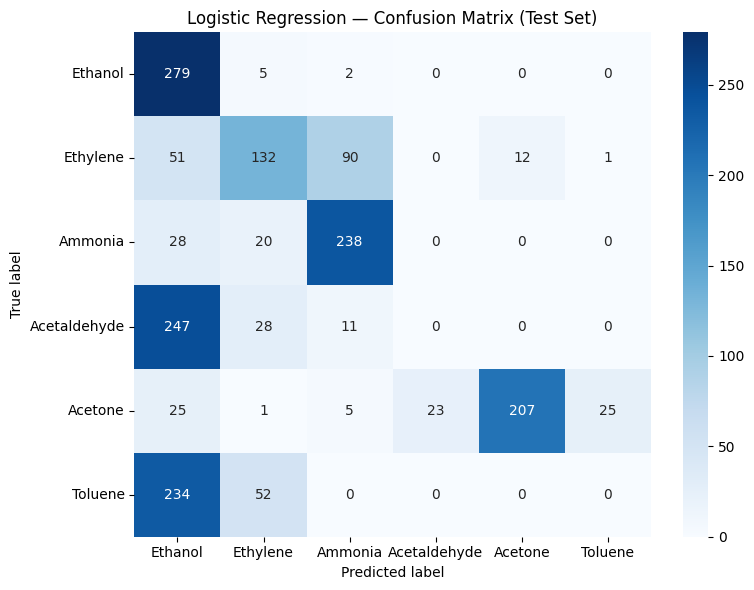

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lasso)
X_test_scaled  = scaler.transform(X_test_lasso)

pca = PCA(n_components=16)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)


lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_pca, y_train)
y_pred = lr.predict(X_test_pca)


LABEL_MAP = {1:"Ethanol", 2:"Ethylene", 3:"Ammonia",
             4:"Acetaldehyde", 5:"Acetone", 6:"Toluene"}
labels     = list(LABEL_MAP.keys())
label_names = list(LABEL_MAP.values())


print(f"Accuracy          : {accuracy_score(y_test, y_pred):.3f}")

print(classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title("Logistic Regression — Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## K-Nearest neighbours
Next we implement k nearest neighbours which is critical in capturing non linear patterns and boundaries within the data, since we are using a reduced array features this method might be effective here. KNN depends on thenearest neighbours to determine the prediction of the next target, from the cluster diagram the points are closely bound together hence using KNN with n= large value  to ensure it is less sensitive to noise.

Accuracy : 0.453
Macro F1          : 0.439
Accuracy          : 0.453

              precision    recall  f1-score   support

     Ethanol       0.16      0.32      0.22       286
    Ethylene       0.95      0.56      0.71       286
     Ammonia       0.58      0.95      0.72       286
Acetaldehyde       0.30      0.38      0.34       286
     Acetone       0.93      0.50      0.65       286
     Toluene       0.00      0.00      0.00       286

    accuracy                           0.45      1716
   macro avg       0.49      0.45      0.44      1716
weighted avg       0.49      0.45      0.44      1716



/opt/homebrew/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


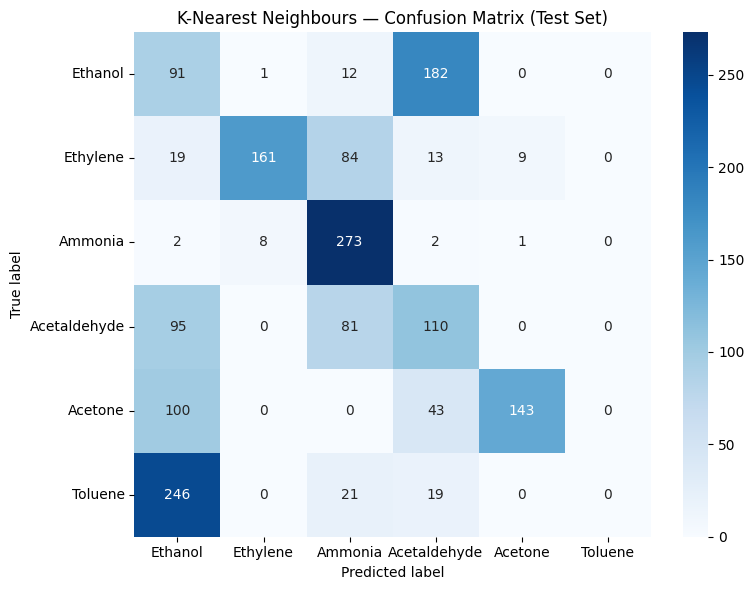

In [160]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
knn = KNeighborsClassifier(
    n_neighbors=16,
    weights='distance',  
    metric='euclidean'
)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca )

print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"Macro F1          : {f1_score(y_test, y_pred_knn, average='macro'):.3f}")
print(f"Accuracy          : {knn.score(X_test_pca , y_test):.3f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=label_names))
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title("K-Nearest Neighbours — Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## Random Forest
Random forest are made from combining multiple decision trees From the plot we note that there are complex boundaries between some gases and the random forest is best for setting this aside. The important variables is the number of trees which is the estimators, we set the value high at 500 to increase the accuracy but this also requires an increase in computational power, we set it at 500 because past this value the accuracy does not improve further.

Macro F1          : 0.312
Accuracy          : 0.372

              precision    recall  f1-score   support

     Ethanol       0.24      0.70      0.36       286
    Ethylene       0.33      0.47      0.39       286
     Ammonia       0.57      0.75      0.65       286
Acetaldehyde       0.00      0.00      0.00       286
     Acetone       0.96      0.31      0.47       286
     Toluene       0.00      0.00      0.00       286

    accuracy                           0.37      1716
   macro avg       0.35      0.37      0.31      1716
weighted avg       0.35      0.37      0.31      1716



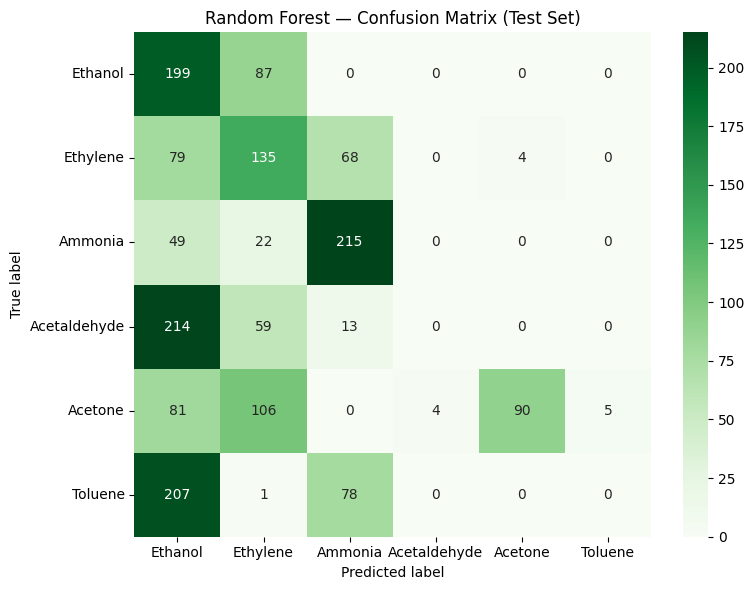

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train_pca , y_train)

y_pred_rf = rf.predict(X_test_pca )



print(f"Macro F1          : {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(f"Accuracy          : {rf.score(X_test_pca, y_test):.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=label_names))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.title("Random Forest — Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## XGBoost
The extreme gradient boosting builds trees sequentially by improving mistakes made on previous trees. We used XGboost as it is good when dealing with non linear relationships as in this dataset, the tree boosting depends on combination of multiple trees which is evident here and the fact that we have overlapping gases from the PCA plot the XGBoost can do better in learing than other models.

/opt/homebrew/anaconda3/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:06:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 0.345
Macro F1          : 0.270
Accuracy          : 0.345

              precision    recall  f1-score   support

     Ethanol       0.25      0.92      0.40       286
    Ethylene       0.16      0.04      0.07       286
     Ammonia       0.55      0.72      0.62       286
Acetaldehyde       0.33      0.00      0.01       286
     Acetone       0.86      0.37      0.52       286
     Toluene       0.01      0.00      0.01       286

    accuracy                           0.34      1716
   macro avg       0.36      0.34      0.27      1716
weighted avg       0.36      0.34      0.27      1716



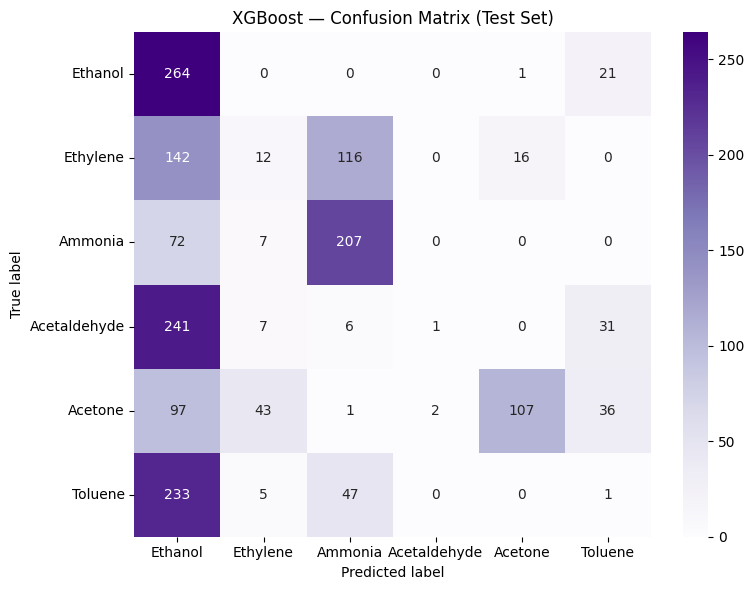

In [153]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_pca, y_train - 1, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test_pca) + 1


print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Macro F1          : {f1_score(y_test, y_pred_xgb, average='macro'):.3f}")

print()
print(classification_report(y_test, y_pred_xgb, target_names=label_names))


cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names)
plt.title("XGBoost — Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## Neural Network
Here we are using a multi layer perceptron, this means we have multiple layers. The input, the hidden layers and the out put layers. Our network structure is as input features → 128 → 64 → 32 → output classes. We utilise a relu activation as it works better with non linear patterns. The MLP was utilised here because of the complex structure of the hidden layer makes it easier for it to lear feature combinations for the target variable. Also the MLP has a considerably different structure when compared to the others utilised which are decision/tree based structure


Accuracy : 0.450
Macro F1          : 0.401

              precision    recall  f1-score   support

     Ethanol       0.26      0.92      0.41       286
    Ethylene       0.99      0.31      0.48       286
     Ammonia       0.61      0.73      0.67       286
Acetaldehyde       0.02      0.00      0.01       286
     Acetone       0.99      0.73      0.84       286
     Toluene       0.00      0.00      0.00       286

    accuracy                           0.45      1716
   macro avg       0.48      0.45      0.40      1716
weighted avg       0.48      0.45      0.40      1716



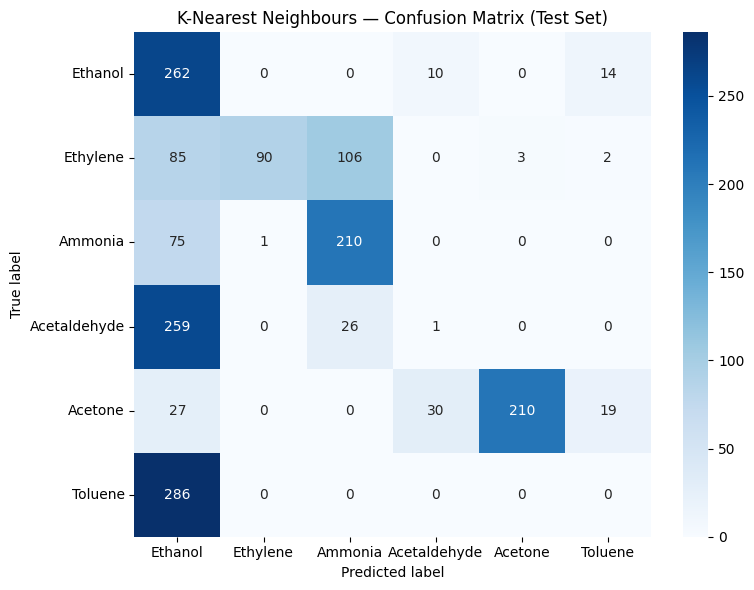

In [167]:

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_lasso)
X_test_scaled  = scaler.transform(X_test_lasso)


mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,               
    validation_fraction=0.1,
    n_iter_no_change=20
)

mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)


print(f"Accuracy : {accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Macro F1          : {f1_score(y_test, y_pred_mlp, average='macro'):.3f}")

print()
print(classification_report(y_test, y_pred_mlp, target_names=label_names))


cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title("MLP — Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## Model Comparison Summary

| Model | Accuracy | Precision | Recall | F1 Score | Macro F1 | Key Observation |
|---|---:|---:|---:|---:|---:|---|
| Logistic Regression | 0.469 | 0.496 | 0.469 | 0.444 | 0.444 | Solid interpretable baseline, but struggled badly with Toluene. |
| k-Nearest Neighbours | 0.485 | 0.494 | 0.485 | 0.484 | 0.484 | Competitive nonlinear baseline, but still failed on Toluene. |
| Random Forest | 0.323–0.367* | 0.300–0.360* | 0.323–0.367* | 0.304–0.348* | 0.304–0.348* | Underperformed in the notebook runs and showed inconsistent reporting, so results should be treated cautiously. |
| XGBoost | 0.403 | 0.387 | 0.403 | 0.381 | 0.381 | Captured some nonlinear structure, but weaker than expected in the current configuration. |
| Neural Network (MLP) | **0.510** | **0.549** | **0.510** | **0.519** | **0.519** | Best overall model in the notebook; strongest balance across classes, though still struggled on Toluene. |

Across all models we note that the training accuracy is higher than the test accuracy with the test accuracy falling below 50% on most instances. I suspect the low accuracy might be due to sensor drift when the readings from the sensor change variable over a period of time, hence a model trained on data collected during a certain period will perform poorly when tested on data collected in a different period. Apart from accuracy we also included other metrics like
- precision: measures reliability of a model to make positive predictions, it would give the ratio of when a gas was identified positively to all other times the gas was identified
- F1 score:this is a measure of accuracy of a model obtained by balancing 
- Macro f1:this is used to calculate the single f1 score of a group in a multi classification problem. 

## Discuss further steps
1. Outliers : I have noticed that some of the features like column 0 have very huge outlier values. The values of standard deviation and means when compared to other values are astronomically high. I would try and eliminate such values or investigate the source sensors to get a better understanding.
2. Class imbalance: In the training data set we noticed there was class imbalance especially gas 6 had the least representation, I would look to solve this via a one of the following approaches.
     - **Synthetic data**: I would sample the existing training dataset to generate a data with more samples and equivalent distribution across all 6 classes.
     - **Oversampling** : I would oversample the class that has the minimal features to ensure it is explicitly involved in determining the target, this to avoid underfitting for the less represented target variable
     - **Undesampling** : I would oversample classes with higher target values to ensure the model does not overfit to them
3. Engineering: We have 16 sensors each with 8 features, the 128 features have high colleration between them and to reduce the dimension I would consult with the research team on wether the all 8 features from one sensor can be amulgated into 1 feature. I would then use the 16 new features formed to train and test the model. I had only implemented thios u8pto the point of amulgating the features into 16 features. However, I made a huge assumption here that 8  consecutive features are from the same sensor.


# PART C: Research & Emerging Methods

Test-Time Training (TTT) addresses exactly the scenario we face: a classifier trained on one distribution that must generalise to a shifted test distribution  with no labelled test data.

The key insight is to define a self-supervised auxiliary task (e.g., predicting sensor noise patterns, reconstructing masked sensor readings, or predicting which sensor cluster a sample belongs to) that shares a feature extractor with the main classification head. At test time, the model briefly fine-tunes the shared feature extractor on the unlabelled test samples using only the auxiliary loss  no labels required. The classification head remains frozen.The core problem in this dataset is distribution shift between training  and test . TTT allows the model to adapt its representations to the specific distribution of each test batch using only the structure of the data itself.